# First creep-life estimate: process -> tube-wall temperature -> life

Calibrated coupled model (alpha_top fixed at 0.182; F_gt, L_q, f_htg from `latham_fit.yaml`,
`calibration_alpha_top_fixed`) for Plants A, B, C2. Along the tube: hoop stress from the local pressure
(mean-diameter formula, wall 15 mm assumed), time-to-rupture from the Larson-Miller master curve at (i) the
outer-wall temperature and (ii) the mid-wall temperature (T_wo + T_wi)/2; minimum along the tube = life-limiting
location; life at the tube-average temperature for Yeh's "average vs maximum" contrast; sensitivity to a +/-10 K,
+/-20 K shift of the peak and to wall thickness 12/15/18 mm.

**Caveat.** The master curve is Yeh (2021)'s Manaurite XM figure (minimum curve, C = 22.96), digitised by pixel
extraction from the PDF and stored as a **placeholder** in `data/creep_derived/yeh2021_manaurite_xm.yaml` until
the NIMS 16B/38A sheets are processed. Absolute lives below are indicative only; the relative comparisons
(outer vs mid-wall, maximum vs average, sensitivities) are the robust part.

In [1]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from rdt import creep
from rdt import latham_calibration as cal
from rdt import latham_cases as lc

fit_path = Path("..") / "data" / "literature_validation" / "latham_fit.yaml"
doc = yaml.safe_load(fit_path.read_text())
bf = doc["calibration_alpha_top_fixed"]["best_fit"]
if "full_parameters" in bf:
    p_fit = lc.LathamParams(**bf["full_parameters"])
else:
    p_fit = replace(cal.BASE, alpha_top=0.182, **bf["params"])
print("configuration:", p_fit)
curve = creep.LarsonMillerCurve.from_yaml()
print(f"master curve: {curve.alloy}; curve = {curve.curve_kind}; C = {curve.C}; fit degree {curve.degree}; LMP range {curve.lmp_range}")
print(f"Yeh design anchor 1198 K, 11.9 MPa -> t_r = {float(curve.time_to_rupture(1198.15, 11.9)):.3g} h (Yeh: ~5e6 h)")
print(f"life-halving temperature step at 1150 K, 12.2 MPa: {curve.life_halving_dT(1150.0, 12.2):.1f} K")


configuration: LathamParams(L_q=0.45596009221697514, alpha_top=0.182, f_htg=1.834547050621761, voidage=0.607, activity=0.2, eta=0.1, eta_top=0.05, f_ctube=0.38, F_gt=0.32343568209185497, f_loss=0.02, tube_od_m=0.146, wall_thickness_m=0.015, heated_length_m=12.5, lambda_tube=29.6, d_p_m=0.0054, rho_bed=1100.0, heat_transfer='leva_grummer', n_sections=15, inlet_mode='well_mixed_top')
master curve: Manaurite XM (Manoir Industries), HP-Nb micro-alloyed 25Cr-35Ni-Nb-Ti centrifugally cast reformer tube; curve = minimum; C = 22.96; fit degree 3; LMP range (30.4998864, 40.500060000000005)
Yeh design anchor 1198 K, 11.9 MPa -> t_r = 5.77e+06 h (Yeh: ~5e6 h)
life-halving temperature step at 1150 K, 12.2 MPa: 11.2 K


In [2]:
rows = cal.case_rows()
results = {}; table = []
for row in rows:
    res = lc.run_case(row, p_fit)
    z, T_wo, T_wi, P = res.z, res.T_wo, res.T_wi, res.tube.P
    T_mid = 0.5 * (T_wo + T_wi)
    lo = creep.life_along_tube(z, T_wo, P, p_fit.tube_od_m, p_fit.wall_thickness_m, curve)
    lm = creep.life_along_tube(z, T_mid, P, p_fit.tube_od_m, p_fit.wall_thickness_m, curve)
    # life at the tube-average temperature and average stress (Yeh's "average" basis)
    t_avg_o = float(curve.time_to_rupture(lo["T_mean_K"], lo["sigma_mean_MPa"]))
    t_avg_m = float(curve.time_to_rupture(lm["T_mean_K"], lm["sigma_mean_MPa"]))
    results[row.case] = {"res": res, "T_mid": T_mid, "outer": lo, "mid": lm, "t_avg_outer_h": t_avg_o, "t_avg_mid_h": t_avg_m}
    table.append({"case": row.case, "rate_%": int(row.plant_rate_pct),
                  "T_wo_max_K": float(T_wo.max()), "z_frac_T_wo_max": float(z[T_wo.argmax()] / z[-1]),
                  "sigma_at_min_MPa": lo["sigma_at_min_MPa"],
                  "t_r_min_outer_h": lo["t_r_min_h"], "t_r_min_outer_yr": lo["t_r_min_years"], "z_frac_min_outer": lo["z_frac_min"],
                  "t_r_min_mid_h": lm["t_r_min_h"], "t_r_min_mid_yr": lm["t_r_min_years"], "z_frac_min_mid": lm["z_frac_min"],
                  "T_wo_mean_K": lo["T_mean_K"], "t_r_avg_outer_yr": t_avg_o / 8760, "t_r_avg_mid_yr": t_avg_m / 8760,
                  "ratio_avg_to_min_outer": t_avg_o / lo["t_r_min_h"]})
tab = pd.DataFrame(table).set_index("case")
pd.set_option("display.width", 250); pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(tab.T.to_string())


case                     Plant_A   Plant_B  Plant_C2
rate_%                        99        92        71
T_wo_max_K                  1147      1140      1139
z_frac_T_wo_max             0.43     0.435     0.425
sigma_at_min_MPa           12.88     12.65     12.14
t_r_min_outer_h        7.865e+07 1.362e+08 1.814e+08
t_r_min_outer_yr            8978 1.555e+04 2.071e+04
z_frac_min_outer           0.425      0.43     0.425
t_r_min_mid_h          2.606e+08 2.872e+08 4.228e+08
t_r_min_mid_yr         2.975e+04 3.279e+04 4.826e+04
z_frac_min_mid                 1         1         1
T_wo_mean_K                 1074      1070      1070
t_r_avg_outer_yr       1.147e+06  1.71e+06 2.213e+06
t_r_avg_mid_yr         3.672e+06 4.957e+06 5.047e+06
ratio_avg_to_min_outer     127.7       110     106.9


In [3]:
# Sensitivity for Plant A: peak temperature shift and wall thickness
rowA = rows[0]; A = results["Plant_A"]
T_pk, s_pk = A["outer"]["T_at_min_K"], A["outer"]["sigma_at_min_MPa"]
sens = []
for dT in (-20, -10, 0, 10, 20):
    t = float(curve.time_to_rupture(T_pk + dT, s_pk))
    sens.append({"perturbation": f"T_wo peak {dT:+d} K", "T_K": T_pk + dT, "sigma_MPa": s_pk, "t_r_h": t, "t_r_years": t / 8760, "ratio_to_reference": t / A["outer"]["t_r_min_h"]})
for w in (0.012, 0.015, 0.018):
    pw = replace(p_fit, wall_thickness_m=w)
    r = lc.run_case(rowA, pw)
    lw = creep.life_along_tube(r.z, r.T_wo, r.tube.P, pw.tube_od_m, w, curve)
    sens.append({"perturbation": f"wall {1e3*w:.0f} mm (coupled rerun)", "T_K": lw["T_at_min_K"], "sigma_MPa": lw["sigma_at_min_MPa"], "t_r_h": lw["t_r_min_h"], "t_r_years": lw["t_r_min_years"], "ratio_to_reference": lw["t_r_min_h"] / A["outer"]["t_r_min_h"]})
sens = pd.DataFrame(sens).set_index("perturbation")
print("Plant A, life at the life-limiting (hottest) point, outer-wall basis:"); print(sens.to_string())


Plant A, life at the life-limiting (hottest) point, outer-wall basis:
                            T_K  sigma_MPa     t_r_h  t_r_years  ratio_to_reference
perturbation                                                                       
T_wo peak -20 K            1127      12.88 2.776e+08  3.169e+04                3.53
T_wo peak -10 K            1137      12.88 1.469e+08  1.677e+04               1.868
T_wo peak +0 K             1147      12.88 7.865e+07       8978                   1
T_wo peak +10 K            1157      12.88 4.255e+07       4858              0.5411
T_wo peak +20 K            1167      12.88 2.327e+07       2656              0.2958
wall 12 mm (coupled rerun) 1140      16.52 2.563e+07       2926              0.3259
wall 15 mm (coupled rerun) 1147      12.88 7.865e+07       8978                   1
wall 18 mm (coupled rerun) 1154      10.44  1.65e+08  1.883e+04               2.098


saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig06_creep_life_profile.png


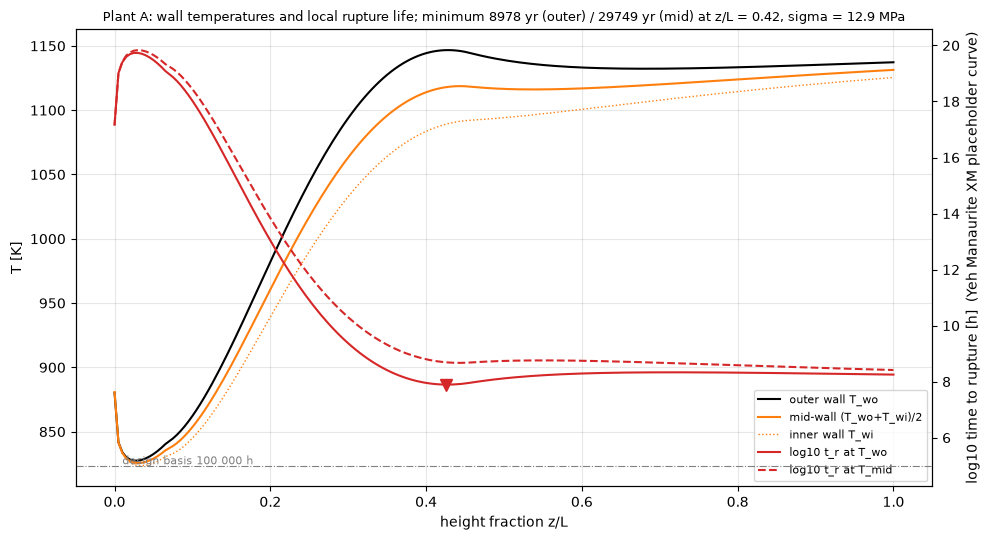

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 5.5))
z = A["res"].z; zf = z / z[-1]
ax1.plot(zf, A["res"].T_wo, "k-", label="outer wall T_wo")
ax1.plot(zf, A["T_mid"], color="C1", label="mid-wall (T_wo+T_wi)/2")
ax1.plot(zf, A["res"].T_wi, color="C1", ls=":", lw=1, label="inner wall T_wi")
ax1.set_xlabel("height fraction z/L"); ax1.set_ylabel("T [K]"); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(zf, A["outer"]["log10_t_r"], "C3-", label="log10 t_r at T_wo")
ax2.plot(zf, A["mid"]["log10_t_r"], "C3--", label="log10 t_r at T_mid")
ax2.axhline(np.log10(1e5), color="grey", lw=0.8, ls="-."); ax2.text(0.01, np.log10(1e5) + 0.05, "design basis 100 000 h", fontsize=8, color="grey")
ax2.plot([A["outer"]["z_frac_min"]], [np.log10(A["outer"]["t_r_min_h"])], "C3v", ms=9)
ax2.set_ylabel("log10 time to rupture [h]  (Yeh Manaurite XM placeholder curve)")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc="lower right")
ax1.set_title(f"Plant A: wall temperatures and local rupture life; minimum {A['outer']['t_r_min_years']:.0f} yr (outer) / {A['mid']['t_r_min_years']:.0f} yr (mid) at z/L = {A['outer']['z_frac_min']:.2f}, sigma = {A['outer']['sigma_at_min_MPa']:.1f} MPa", fontsize=9)
fig.tight_layout()
out = Path("..") / "paper" / "figures" / "fig06_creep_life_profile.png"
fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()


In [5]:
def py(o):
    if isinstance(o, dict): return {str(k): py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [py(v) for v in o]
    if isinstance(o, np.ndarray): return [float(v) for v in o]
    if isinstance(o, (np.floating, np.integer)): return o.item()
    return o
doc["creep_life_first_estimate"] = {
    "configuration": "calibration_alpha_top_fixed best fit; wall 15 mm assumed; mean-diameter hoop stress; Larson-Miller C = 22.96, Yeh 2021 Manaurite XM minimum curve (PLACEHOLDER, pixel-digitised)",
    "caveat": "absolute lives indicative only until NIMS 16B/38A master curves replace the placeholder; relative comparisons are the robust part",
    "master_curve_file": "data/creep_derived/yeh2021_manaurite_xm.yaml",
    "cases": py(tab.reset_index().to_dict(orient="records")),
    "sensitivity_plant_A_hottest_point": py(sens.reset_index().to_dict(orient="records")),
    "life_halving_dT_K_at_1150K_12MPa": float(curve.life_halving_dT(1150.0, 12.2)),
}
fit_path.write_text(yaml.safe_dump(doc, sort_keys=False, default_flow_style=False, width=130))
print("wrote creep_life_first_estimate to latham_fit.yaml")


wrote creep_life_first_estimate to latham_fit.yaml
